<a href="https://colab.research.google.com/github/fernandolomineth-byte/impulse-digital/blob/main/Te_damos_la_bienvenida_a_Colaboratory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,export_text,plot_tree
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [7]:
#cargar dataset

data=load_breast_cancer()
x=data.data
y=data.target
x.shape
y.shape

(569,)

In [8]:
print(data.feature_names)
print(data.data)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
[[1.799e+01 1.038e+01 1.228e+02 ... 2.654e-01 4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 ... 1.860e-01 2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 ... 2.430e-01 3.613e-01 8.758e-02]
 ...
 [1.660e+01 2.808e+01 1.083e+02 ... 1.418e-01 2.218e-01 7.820e-02]
 [2.060e+01 2.933e+01 1.401e+02 ... 2.650e-01 4.087e-01 1.240e-01]
 [7.760e+00 2.454e+01 4.792e+01 ... 0.000e+00 2.871e-01 7.039e-02]]


In [9]:
print(data.target_names)
print(data.target)

['malignant' 'benign']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 0 0 0 1 1
 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0
 0 1 0 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1
 1

In [25]:

X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.25,stratify=y,random_state=42)

In [12]:
modelo=DecisionTreeClassifier(random_state=0,criterion='gini')

In [26]:
modelo.fit(X_train,y_train)

DecisionTreeClassifier(random_state=0)

In [27]:
#clasificar
y_pred=modelo.predict(X_test)

In [28]:
accuracy=accuracy_score(y_test,y_pred)
print(f'Exactitud (acuracy): {accuracy:3f}')

Exactitud (acuracy): 0.937063


In [29]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[49  4]
 [ 5 85]]


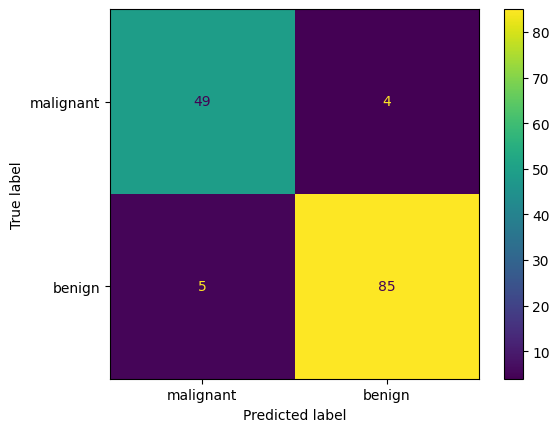

In [30]:
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=data.target_names)
disp.plot()

In [31]:
tree_rules=export_text(modelo,feature_names=data.feature_names)
print(tree_rules)

|--- worst radius <= 16.80
|   |--- worst concave points <= 0.14
|   |   |--- radius error <= 1.05
|   |   |   |--- smoothness error <= 0.00
|   |   |   |   |--- mean texture <= 19.90
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- mean texture >  19.90
|   |   |   |   |   |--- class: 0
|   |   |   |--- smoothness error >  0.00
|   |   |   |   |--- area error <= 48.70
|   |   |   |   |   |--- worst texture <= 33.35
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- worst texture >  33.35
|   |   |   |   |   |   |--- worst texture <= 33.80
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- worst texture >  33.80
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- area error >  48.70
|   |   |   |   |   |--- mean concavity <= 0.03
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- mean concavity >  0.03
|   |   |   |   |   |   |--- class: 1
|   |   |--- radius error >  1.05
|   |   |   |--- class: 0
|   |--- worst concave poin

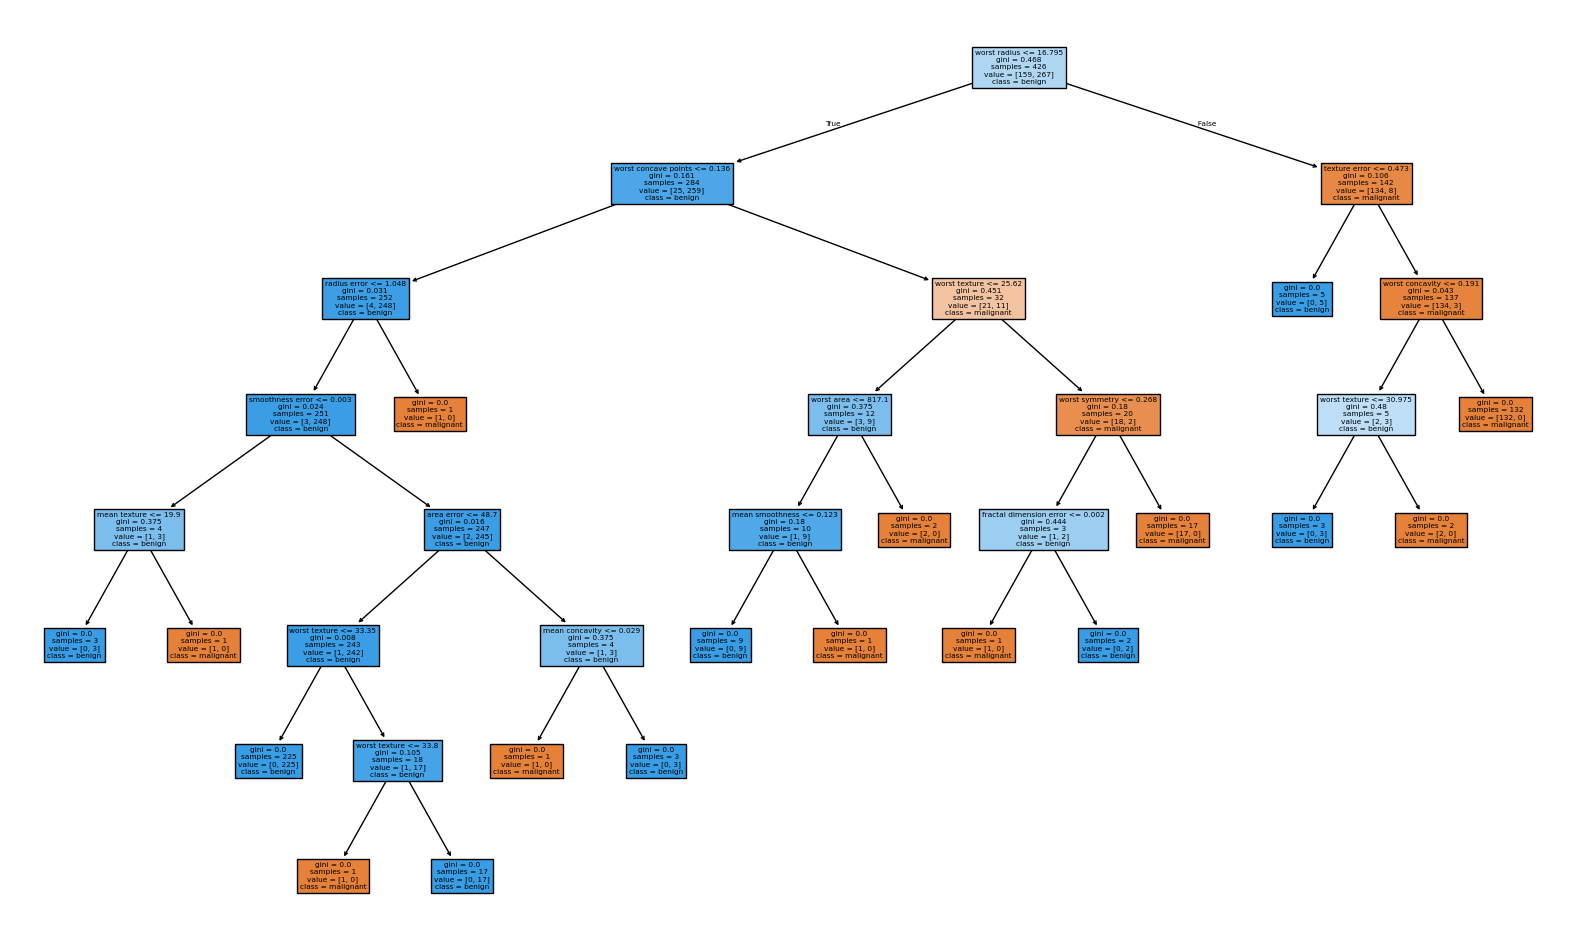

In [33]:
plt.figure(figsize=(20,12))
plot_tree(modelo,feature_names=data.feature_names,class_names=data.target_names,filled=True)
plt.show()